# Train a Convolutional Autoencoder on IU X-Ray (Colab)

Pretrains a `ConvEncoder` that will later replace R2Gen's ResNet50 visual extractor.

**Contract this notebook must satisfy** (so the encoder drops into R2Gen unchanged later):
- Input: `224x224x3`, ImageNet-normalized (mean `(0.485, 0.456, 0.406)`, std `(0.229, 0.224, 0.225)`) — **not** `[0,1]`.
- Encoder output (bottleneck): `[B, 256, 14, 14]` → later reshaped to 196 spatial tokens (`d_vf=256`).
- Decoder's final layer is **linear** (no sigmoid/tanh), and the loss is plain **MSE** in normalized space — because the targets are ImageNet-normalized, not `[0,1]` images.
- Trained only on the **train split** of IU X-Ray (both frontal + lateral images, treated as independent samples) to avoid leaking val/test images into the pretrained features.

Only the trained **encoder** weights are exported at the end (`ae_encoder.pth`) — that's the file you bring back to the R2Gen repo for Phase 3 integration.

## 1. Setup

In [24]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only — go to Runtime > Change runtime type > GPU')

CUDA available: True
Device name: Tesla T4


## 2. Get the IU X-Ray data onto the Colab instance

You need `data/iu_xray/annotation.json` and `data/iu_xray/images/<study_id>/{0,1}.png` available on this VM.

Pick **one** of the two options below.

In [22]:
import os

# 1. Install gdown
!pip install gdown -q

# 2. Navigate to the /content directory
os.chdir('/content')
print(f"Current working directory: {os.getcwd()}")

# 3. Download the iu_xray.zip file
!gdown --id 1c0BXEuDy8Cmm2jfN0YYGkQxFZd2ZIoLg -O iu_xray.zip

print("\n✅ iu_xray.zip downloaded successfully.")
!unzip /content/iu_xray.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/iu_xray/images/CXR974_IM-2463/1.png  
  inflating: /content/data/iu_xray/images/CXR974_IM-2463/0.png  
  inflating: /content/data/iu_xray/images/CXR974_IM-2463/2.png  
   creating: /content/data/iu_xray/images/CXR2413_IM-0959/
  inflating: /content/data/iu_xray/images/CXR2413_IM-0959/1.png  
  inflating: /content/data/iu_xray/images/CXR2413_IM-0959/0.png  
   creating: /content/data/iu_xray/images/CXR19_IM-0583/
  inflating: /content/data/iu_xray/images/CXR19_IM-0583/1.png  
  inflating: /content/data/iu_xray/images/CXR19_IM-0583/0.png  
   creating: /content/data/iu_xray/images/CXR907_IM-2412/
  inflating: /content/data/iu_xray/images/CXR907_IM-2412/1.png  
  inflating: /content/data/iu_xray/images/CXR907_IM-2412/0.png  
   creating: /content/data/iu_xray/images/CXR1076_IM-0054/
  inflating: /content/data/iu_xray/images/CXR1076_IM-0054/1.png  
  inflating: /content/data/iu_xray/images/CXR1076_IM-0054/0.png  

## 3. Autoencoder architecture

Identical to `modules/autoencoder.py` in the R2Gen repo — kept in sync manually since Colab doesn't have the repo checked out. If you change one, change the other.

In [23]:
import torch
import torch.nn as nn


class ConvEncoder(nn.Module):
    """Encodes a 224x224x3 image to a [B, 256, 14, 14] feature map."""

    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)  # [B, 256, 14, 14] for 224x224 input


class ConvDecoder(nn.Module):
    """Mirrors ConvEncoder: [B, 256, 14, 14] -> [B, 3, 224, 224]. Linear output (no activation) since
    targets are ImageNet-normalized, not in [0, 1]."""

    def __init__(self, out_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, out_channels, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)  # [B, 3, 224, 224]


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ConvEncoder()
        self.decoder = ConvDecoder()

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


# Sanity check on shapes
_m = ConvAutoencoder()
_recon, _z = _m(torch.randn(2, 3, 224, 224))
assert _z.shape == (2, 256, 14, 14), _z.shape
assert _recon.shape == (2, 3, 224, 224), _recon.shape
print('Architecture OK. Bottleneck:', tuple(_z.shape), '-> d_vf=256, 196 tokens')
del _m, _recon, _z

Architecture OK. Bottleneck: (2, 256, 14, 14) -> d_vf=256, 196 tokens


## 4. Dataset

Reads `annotation.json`, uses **train split only**, pools frontal + lateral images as independent training samples (2069 train studies × 2 images ≈ 4138 images).

Transform matches `modules/dataloaders.py`'s train transform exactly, so the encoder sees the same input distribution it will see when plugged into R2Gen.

In [26]:
import os
import json
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class IuxrayAEDataset(Dataset):
    """Flat dataset of individual images (frontal + lateral pooled) from the train split,
    for unsupervised autoencoder pretraining."""

    def __init__(self, data_root, split='train', transform=None):
        self.image_dir = os.path.join(data_root, 'images')
        ann_path = os.path.join(data_root, 'annotation.json')
        ann = json.loads(open(ann_path, 'r').read())
        self.transform = transform

        self.image_paths = []
        for example in ann[split]:
            for rel_path in example['image_path']:
                self.image_paths.append(rel_path)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = os.path.join(self.image_dir, self.image_paths[idx])
        image = Image.open(path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image

DATA_ROOT = '/content/data/iu_xray'
train_dataset = IuxrayAEDataset(DATA_ROOT, split='train', transform=train_transform)
print('Train images:', len(train_dataset))

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

Train images: 4138


## 5. Train

In [27]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EPOCHS = 60
LR = 1e-3

model = ConvAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
criterion = nn.MSELoss()

loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for images in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, _ = model(images)
        loss = criterion(recon, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    loss_history.append(epoch_loss)
    scheduler.step()

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f'Epoch {epoch:3d}/{EPOCHS} | MSE: {epoch_loss:.4f} | lr: {optimizer.param_groups[0]["lr"]:.2e}')

print('Final train MSE:', loss_history[-1])

Epoch   1/60 | MSE: 0.1183 | lr: 1.00e-03
Epoch   5/60 | MSE: 0.0198 | lr: 1.00e-03
Epoch  10/60 | MSE: 0.0180 | lr: 1.00e-03
Epoch  15/60 | MSE: 0.0151 | lr: 1.00e-03
Epoch  20/60 | MSE: 0.0143 | lr: 1.00e-03
Epoch  25/60 | MSE: 0.0136 | lr: 1.00e-03
Epoch  30/60 | MSE: 0.0122 | lr: 5.00e-04
Epoch  35/60 | MSE: 0.0114 | lr: 5.00e-04
Epoch  40/60 | MSE: 0.0127 | lr: 5.00e-04
Epoch  45/60 | MSE: 0.0120 | lr: 5.00e-04
Epoch  50/60 | MSE: 0.0110 | lr: 5.00e-04
Epoch  55/60 | MSE: 0.0117 | lr: 5.00e-04
Epoch  60/60 | MSE: 0.0109 | lr: 2.50e-04
Final train MSE: 0.010918392839856399


## 6. Loss curve

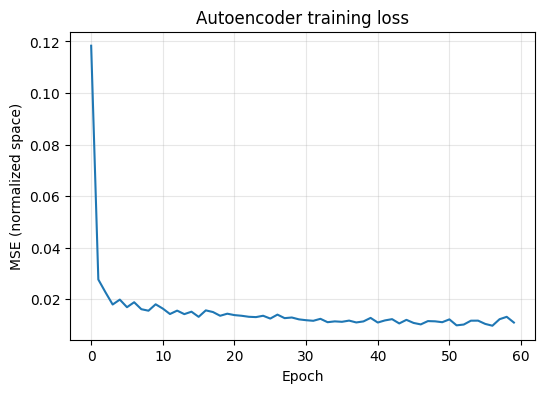

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized space)')
plt.title('Autoencoder training loss')
plt.grid(alpha=0.3)
plt.show()

## 7. Visualize reconstructions

Denormalizes back to `[0,1]` for display. Reconstructions won't be perfect — the bottleneck is a 196-token compression — but you should see the model recovering rib cage / lung field / overall anatomy structure, not noise.

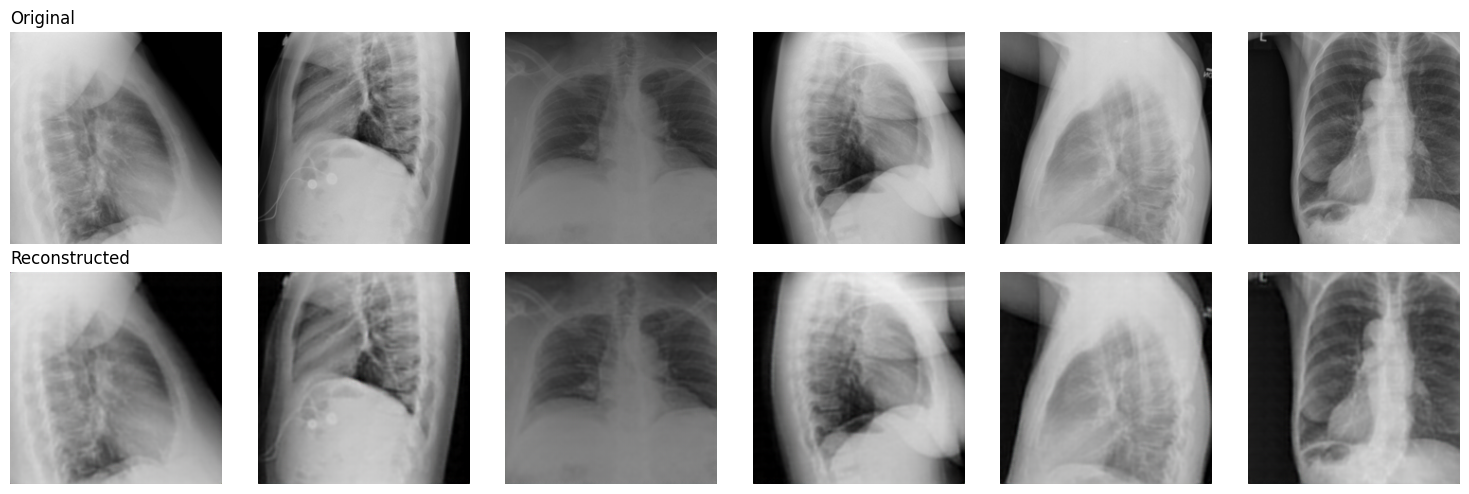

In [29]:
import numpy as np

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

model.eval()
with torch.no_grad():
    sample_images = next(iter(train_loader))[:6].to(device)
    sample_recon, _ = model(sample_images)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    orig = denormalize(sample_images[i]).permute(1, 2, 0).numpy()
    recon = denormalize(sample_recon[i]).permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon)
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', loc='left')
axes[1, 0].set_title('Reconstructed', loc='left')
plt.tight_layout()
plt.show()

## 8. Export the encoder

Only the encoder is needed for R2Gen integration — the decoder was just a training scaffold.

In [30]:
torch.save(model.encoder.state_dict(), 'ae_encoder.pth')
print('Saved ae_encoder.pth')

from google.colab import files
files.download('ae_encoder.pth')

# Alternative: save straight to Drive instead of downloading
# import shutil
# shutil.copy('ae_encoder.pth', '/content/drive/MyDrive/ae_encoder.pth')

Saved ae_encoder.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import torch
sd = torch.load('ae_encoder.pth', map_location='cpu')
for k, v in sd.items():
    print(k, tuple(v.shape))


net.0.weight (32, 3, 3, 3)
net.0.bias (32,)
net.1.weight (32,)
net.1.bias (32,)
net.1.running_mean (32,)
net.1.running_var (32,)
net.1.num_batches_tracked ()
net.3.weight (64, 32, 3, 3)
net.3.bias (64,)
net.4.weight (64,)
net.4.bias (64,)
net.4.running_mean (64,)
net.4.running_var (64,)
net.4.num_batches_tracked ()
net.6.weight (128, 64, 3, 3)
net.6.bias (128,)
net.7.weight (128,)
net.7.bias (128,)
net.7.running_mean (128,)
net.7.running_var (128,)
net.7.num_batches_tracked ()
net.9.weight (256, 128, 3, 3)
net.9.bias (256,)
net.10.weight (256,)
net.10.bias (256,)
net.10.running_mean (256,)
net.10.running_var (256,)
net.10.num_batches_tracked ()


---
**Next step (not part of this notebook):** bring `ae_encoder.pth` back into the R2Gen repo. It will be loaded by an `AutoencoderVisualExtractor` wired into `modules/visual_extractor.py` (Phase 3, not done yet).